## 01c Experiment 1a: Category Membership - Items Task Analysis

In [ ]:
# Setup
import pandas as pd
import csv
import matplotlib.pyplot as plt
import numpy as np
import string
from tabulate import tabulate
from collections import defaultdict
import random
import pickle
import seaborn as sns
import ast
from matplotlib.cm import get_cmap

In [2]:
# Attributes + Items Categories
# FURNITURE # WEAPON # VEHICLE # FRUIT # VEGETABLE # CLOTHING

# Only Items Categories:
# BIRD # CARPENTER'S TOOL # SPORT # TOY

In [ ]:
# Importing data

items_df  = pd.read_csv('01_catmemexp_itemstask_allmodels_processed_FINAL.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding = "utf-8")
items_df.head()

In [44]:
items_df['output_list_processed_nonoise'] = items_df['output_list_processed_nonoise'].apply(ast.literal_eval)

In [45]:
items_df.loc[items_df['model'] == 'deepseek-chat', 'model'] = 'DeepSeek'
items_df.loc[items_df['model'] == 'gemini-3-pro', 'model'] = 'Gemini 3 Pro'
items_df.loc[items_df['model'] == 'gpt-5.2', 'model'] = 'GPT-5.2'

#### Order

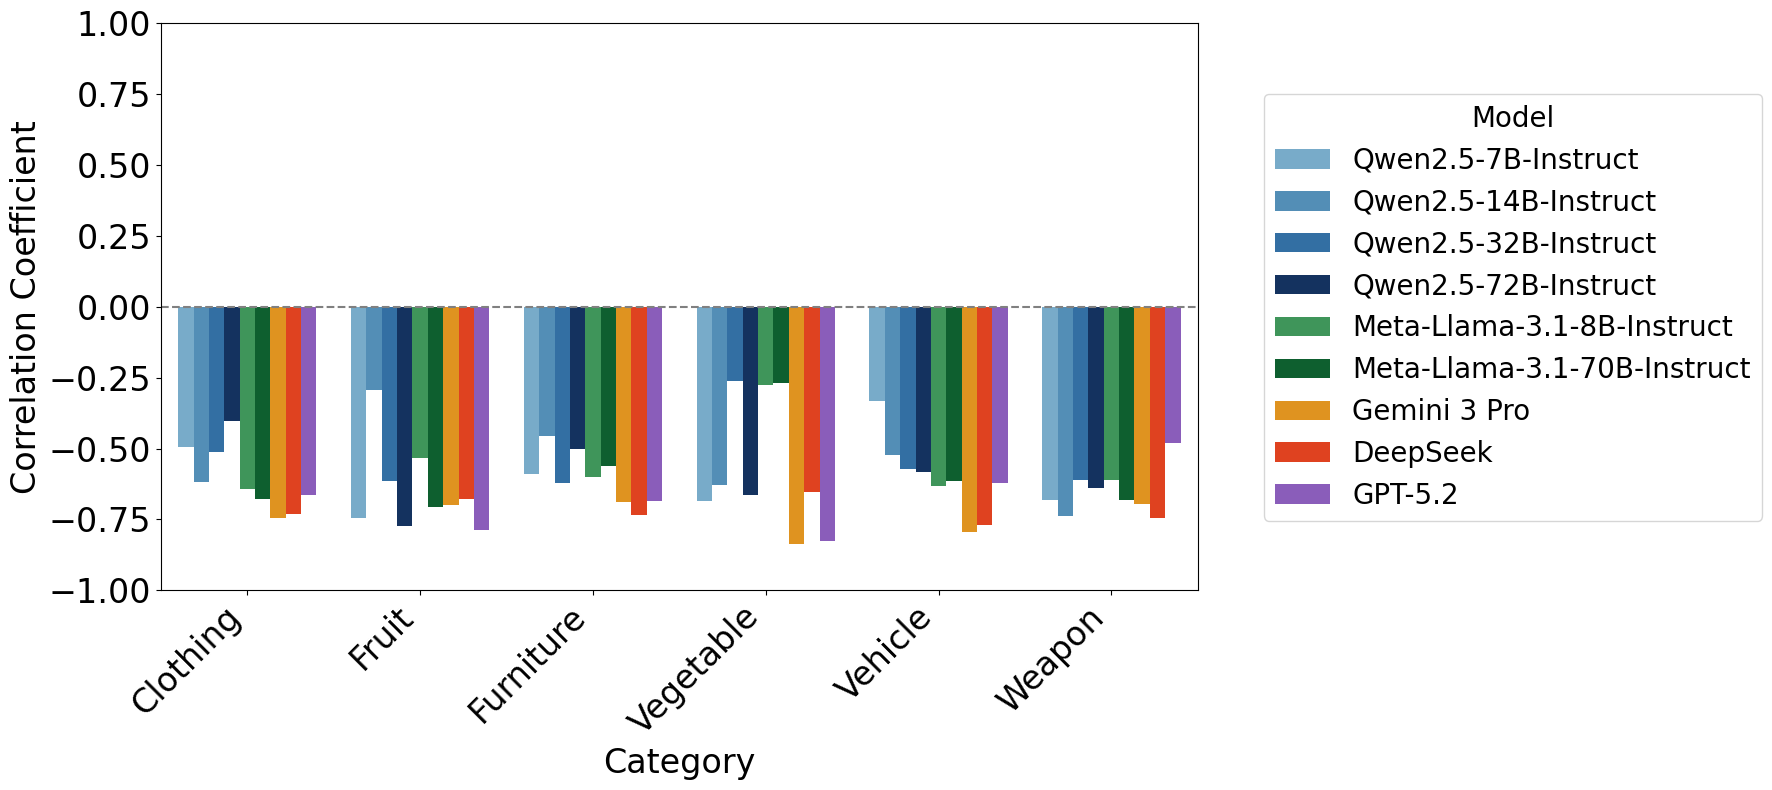

In [ ]:
# Correlation Plots

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Plots
def visualize_correlation_bar_plot(df):
    analysis_data = []

    for (model, category), group in df.groupby(['model', 'category']):
        exploded_items = group['output_list_processed_nonoise'].explode()
        items_count = exploded_items.value_counts()

        for index, row in group.iterrows():
            for output_item in row['output_list_processed_nonoise']:
                item_index = row['output_list_processed_nonoise'].index(output_item) + 1
                analysis_data.append({
                    "model": model,
                    "category": category,
                    "item": output_item,
                    "frequency": items_count.get(output_item, 0),
                    "order": item_index
                })

    df_analysis = pd.DataFrame(analysis_data)

    average_positions = df_analysis.groupby('item')['order'].mean().reset_index()
    average_positions.rename(columns={'order': 'average_order'}, inplace=True)
    df_analysis = df_analysis.merge(average_positions, on='item')

    correlation_results = []

    unique_models = df['model'].unique()

    for model in unique_models:
        model_data = df_analysis[df_analysis['model'] == model]
        unique_categories = model_data['category'].unique()
        for category in unique_categories:
            category_data = model_data[model_data['category'] == category]
            correlation = category_data[['average_order', 'frequency']].corr().iloc[0, 1]
            correlation_results.append({
                'model': model,
                'category': category,
                'correlation': correlation
            })

    df_correlations = pd.DataFrame(correlation_results)

    # Define color palette
    model_palette = {
        'Qwen2.5-7B-Instruct': '#6baed6',  
        'Qwen2.5-14B-Instruct': '#4292c6',
        'Qwen2.5-32B-Instruct': '#2171b5',
        'Qwen2.5-72B-Instruct': '#08306b',
        'Meta-Llama-3.1-8B-Instruct': '#31a354',  
        'Meta-Llama-3.1-70B-Instruct': '#006d2c', 
        'DeepSeek': '#ff2e00',  
        'Gemini 3 Pro': '#ff9900',  
        'GPT-5.2': '#8a4dca'  
    }

    plt.figure(figsize=(18, 8))
    sns.barplot(
        data=df_correlations,
        x='category',
        y='correlation',
        hue='model',
        palette=model_palette
    )

    font_size = 24
    plt.xlabel('Category', fontsize=font_size)
    plt.ylabel('Correlation Coefficient', fontsize=font_size)  
    plt.axhline(0, color='gray', linestyle='--')
    plt.xticks(rotation=45, ha='right', fontsize=font_size)  
    plt.yticks(fontsize=font_size)  
    plt.ylim(-1, 1)
    
    plt.legend(title='Model', loc='upper left', fontsize=font_size-4, title_fontsize=font_size-4, bbox_to_anchor=(1.05, 0.90)) 

    plt.tight_layout()
    plt.savefig('01_ItemsFigures/figure_order_frequency_items.pdf', format='pdf', bbox_inches='tight')  
    plt.show()

visualize_correlation_bar_plot(items_df)


In [ ]:
# Order/Frequency Correlation - Heatmap version (of previous plot)

def visualize_correlation_heatmap(df):
    analysis_data = []

    for (model, category), group in df.groupby(['model', 'category']):
        exploded_items = group['output_list_processed_nonoise'].explode()
        items_count = exploded_items.value_counts()

        for index, row in group.iterrows():
            for output_item in row['output_list_processed_nonoise']:
                item_index = row['output_list_processed_nonoise'].index(output_item) + 1  
                analysis_data.append({
                    "model": model,
                    "category": category,
                    "item": output_item,
                    "frequency": items_count.get(output_item, 0),
                    "order": item_index
                })

    df_analysis = pd.DataFrame(analysis_data)

    average_positions = df_analysis.groupby('item')['order'].mean().reset_index()
    average_positions.rename(columns={'order': 'average_order'}, inplace=True)

    df_analysis = df_analysis.merge(average_positions, on='item')

    correlation_results = []

    unique_models = df['model'].unique()

    for model in unique_models:
        model_data = df_analysis[df_analysis['model'] == model]
        unique_categories = model_data['category'].unique()

        for category in unique_categories:
            category_data = model_data[model_data['category'] == category]
            correlation = category_data[['average_order', 'frequency']].corr().iloc[0, 1]

            correlation_results.append({
                'model': model,
                'category': category,
                'correlation': correlation
            })

    df_correlations = pd.DataFrame(correlation_results)
    
    heatmap_data = df_correlations.pivot(index='model', columns='category', values='correlation')

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        heatmap_data,
        annot=True,
        cmap='coolwarm',
        center=0,
        cbar_kws={"label": "Correlation Coefficient", "ticks": [-1, 0, 1]}, 
        vmin=-1,  
        vmax=1    
    )
    
    plt.title('Average Position vs Frequency Correlation')
    plt.xlabel('Category')
    plt.ylabel('Model')
    
    plt.tight_layout()
    plt.savefig('01_ItemsFigures/correlation_heatmap.pdf', format='pdf') 
    plt.show()

visualize_correlation_heatmap(items_df)

#### Frequency Analyses

In [ ]:
model_items = items_df.explode('output_list_processed_nonoise')
total_item_counts = model_items.groupby('model').size().reset_index(name='total_items')

print(total_item_counts)


                         model  total_items
0                     DeepSeek        24554
1                      GPT-5.2        14933
2                 Gemini 3 Pro        19228
3  Meta-Llama-3.1-70B-Instruct         4858
4   Meta-Llama-3.1-8B-Instruct         4838
5         Qwen2.5-14B-Instruct         3778
6         Qwen2.5-32B-Instruct         4828
7         Qwen2.5-72B-Instruct         4907
8          Qwen2.5-7B-Instruct         2195


In [ ]:
# Unique items per model per category

model_items = items_df.explode('output_list_processed_nonoise')

unique_item_counts = (
    model_items.groupby(['model', 'category'])['output_list_processed_nonoise']
    .nunique()
    .reset_index(name='unique_item_count')
)

print(unique_item_counts)


                          model   category  unique_item_count
0                      DeepSeek   Clothing               1608
1                      DeepSeek      Fruit                 96
2                      DeepSeek  Furniture                777
3                      DeepSeek  Vegetable                 57
4                      DeepSeek    Vehicle                795
5                      DeepSeek     Weapon               1090
6                       GPT-5.2   Clothing                164
7                       GPT-5.2      Fruit                212
8                       GPT-5.2  Furniture                208
9                       GPT-5.2  Vegetable                150
10                      GPT-5.2    Vehicle                181
11                      GPT-5.2     Weapon                145
12                 Gemini 3 Pro   Clothing                244
13                 Gemini 3 Pro      Fruit                140
14                 Gemini 3 Pro  Furniture                212
15      

In [ ]:
#Heatmap
heatmap_data = unique_item_counts.pivot(index='model', columns='category', values='unique_item_count')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='g', cbar_kws={'label': 'Unique Item Count'})

plt.title('Heatmap of Unique Item Counts by Model and Category')
plt.xlabel('Category')
plt.ylabel('Model')

plt.show()

In [ ]:
#Log Heatmap

heatmap_data = unique_item_counts.pivot(index='model', columns='category', values='unique_item_count')


log_heatmap_data = np.log1p(heatmap_data)  


plt.figure(figsize=(12, 8))
sns.heatmap(
    log_heatmap_data,
    annot=heatmap_data,  
    cmap='coolwarm',
    fmt='g',
    cbar_kws={'label': 'Log Scale of Unique Item Count'}
)


plt.xlabel('Category')
plt.ylabel('Model')


plt.savefig('01_ItemsFigures/frequniqueitems_heatmap.pdf', format='pdf') 
plt.show()

In [52]:
# Collecting Item Frequencies per model
model_items = items_df.explode('output_list_processed_nonoise')
item_counts = model_items.groupby(['model','category','output_list_processed_nonoise']).size().reset_index(name='frequency')
item_counts

,model,category,output_list_processed_nonoise,frequency
0,DeepSeek,Clothing,a-line skirt,4
1,DeepSeek,Clothing,abaya,3
2,DeepSeek,Clothing,abstract,4
3,DeepSeek,Clothing,accessorie,2
4,DeepSeek,Clothing,accessorizing,2
...,...,...,...,...
8650,Qwen2.5-7B-Instruct,Weapon,spear,30
8651,Qwen2.5-7B-Instruct,Weapon,staff,19
8652,Qwen2.5-7B-Instruct,Weapon,sword,30
8653,Qwen2.5-7B-Instruct,Weapon,wand,4


In [ ]:
# Collecting Item Frequencies per model
model_items = items_df.explode('output_list_processed_nonoise')

item_counts = model_items.groupby(['model', 'output_list_processed_nonoise']).size().reset_index(name='frequency')

gpt_furniture = item_counts[item_counts['model'] == 'gpt-5.2']

gpt_furniture = gpt_furniture.sort_values(by='frequency', ascending=False)

gpt_furniture_table = pd.DataFrame({
    'model': 'gpt-5.2',  
    'category': 'Furniture',  
    'item': gpt_furniture['output_list_processed_nonoise'], 
    'rank': range(1, len(gpt_furniture) + 1),  
    'frequency': gpt_furniture['frequency'] 
})

gpt_furniture_table = gpt_furniture_table[['model', 'category', 'item', 'rank', 'frequency']] 
print(gpt_furniture_table)

gpt_furniture_table.to_csv('example_table.csv',index=False, quoting=csv.QUOTE_ALL, encoding='utf-8')


Empty DataFrame
Columns: [model, category, item, rank, frequency]
Index: []


In [ ]:
# Function to safely convert strings to lists
def safe_literal_eval(value):
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError) as e:
        print(f"Error parsing value: {value} - {e}")
        return [] 


items_df['output_list_processed'] = items_df['output_list_processed'].apply(safe_literal_eval)


def count_total_items_per_model(df):
    exploded_df = df.explode('output_list_processed')
    total_counts = exploded_df.groupby(['model', 'category'])['output_list_processed'].count().reset_index(name='total_item_count')
    return total_counts


total_item_counts_per_model = count_total_items_per_model(items_df)


print(total_item_counts_per_model)

                          model   category  total_item_count
0                      DeepSeek   Clothing             11553
1                      DeepSeek      Fruit              1682
2                      DeepSeek  Furniture             10829
3                      DeepSeek  Vegetable              1152
4                      DeepSeek    Vehicle              8370
5                      DeepSeek     Weapon             10193
6                       GPT-5.2   Clothing              2411
7                       GPT-5.2      Fruit              2973
8                       GPT-5.2  Furniture              2940
9                       GPT-5.2  Vegetable              2469
10                      GPT-5.2    Vehicle              2637
11                      GPT-5.2     Weapon              1938
12                 Gemini 3 Pro   Clothing              3847
13                 Gemini 3 Pro      Fruit              2518
14                 Gemini 3 Pro  Furniture              3439
15                 Gemin

In [ ]:
pivot_table = total_item_counts_per_model.pivot(index='model', columns='category', values='total_item_count').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap='coolwarm', annot=True, fmt='g', cbar_kws={'label': 'Total Item Count'},linewidths=0, linecolor='white')

plt.xlabel('Category')
plt.ylabel('Model')

plt.tight_layout()
plt.show()

In [ ]:
pivot_table = total_item_counts_per_model.pivot(index='model', columns='category', values='total_item_count').fillna(0)

log_pivot_table = np.log1p(pivot_table) 

plt.figure(figsize=(12, 8))
sns.heatmap(log_pivot_table, cmap='coolwarm', annot=pivot_table, fmt='g', cbar_kws={'label': 'Log of Total Item Count'},linewidths=0, linecolor='white')

plt.xlabel('Category')
plt.ylabel('Model')

plt.tight_layout()
plt.savefig('01_ItemsFigures/freqitems_heatmap.pdf', format='pdf') 
plt.show()

#### Item Selection for Attributes Task

In [ ]:
# Collecting Common Items Between Models for each Category

# Function to find common furniture items across models for each category
def find_common_items(df):
    common_items_per_category = {}
    grouped = df.groupby(['category', 'model'])['output_list_processed'].apply(lambda x: list(set([item for sublist in x for item in sublist]))).reset_index()
    for category, group in grouped.groupby('category'):
        common_items = set(group['output_list_processed'].iloc[0])
        for items in group['output_list_processed'][1:]:
            common_items.intersection_update(set(items))
        common_items_per_category[category] = list(common_items)
    return common_items_per_category

# Collect common items between models per category
common_items = find_common_items(items_df)

common_furniture = common_items['Furniture']
common_weapon = common_items['Weapon']
common_vehicle = common_items['Vehicle']
common_fruit = common_items['Fruit']
common_vegetable = common_items['Vegetable']
common_clothing= common_items['Clothing']

print(common_furniture)

['wardrobe', 'table', 'armchair', 'coffee table', 'loveseat', 'bookshelf', 'ottoman', 'cabinet', 'bed', 'chair', 'nightstand', 'desk', 'dining table', 'sofa', 'end table', 'bench', 'shelf', 'sideboard', 'dresser', 'couch']


In [58]:
len(common_furniture)

20

In [59]:
# Rosch Items for each category (rosch1975c)

rosch_furniture = ["chair", "sofa", "table", "dresser", "desk", "bed", "bookcase", "footstool", "lamp", "piano", "cushion", "mirror", "rug", "radio", "stove", "clock", "picture", "closet", "vase", "telephone"]
rosch_weapon = ["gun","knife","sword","bomb","hand grenade","spear","cannon","bow and arrow","club", "tank", "whip", "icepick", "fists", "rocket", "poison", "scissors", "words", "foot", "screwdriver"]
rosch_vehicle = ["car","truck","bus","motorcycle","train","trolley car", "bicycle","airplane","boat","tractor", "cart","wheelchair","tank","raft","sled","horse","blimp","skates","wheelbarrow","elevator"]
rosch_fruit = ["orange","apple","banana","peach","pear","apricot","plum","grapes","strawberry","grapefruit","pineapple","blueberry","lemon","watermelon","honeydew","pomegranate","date","coconut","tomato","olive"]
rosch_vegetable = ["peas","carrots","string beans","spinach","broccoli","asparagus","corn","cauliflower","brussel sprouts","lettuce","beets","tomato","lima beans","eggplant","onion","potato","yam","mushroom","pumpkin","rice"]
rosch_clothing = ["pants","shirt","dress","skirt","jacket","coat","sweater","underpants","socks","pajamas","bathing suit","shoes","vest","tie","mittens","hat","apron","purse","wristwatch","necklace"]

rosch_items = {
        "Furniture": set(rosch_furniture),
        "Weapon": set(rosch_weapon),
        "Vehicle": set(rosch_vehicle),
        "Fruit": set(rosch_fruit),
        "Vegetable": set(rosch_vegetable),
        "Clothing": set(rosch_clothing)
}

In [ ]:
# FREQUENCY DISTRIBUTION

model_items = items_df.explode('output_list_processed') 
item_counts = model_items.groupby(['model', 'category', 'output_list_processed']).size().reset_index(name='frequency')


unique_models = item_counts['model'].unique()

for model in unique_models:
    plt.figure(figsize=(16, 10))  
    
    model_data = item_counts[item_counts['model'] == model]
    unique_categories = model_data['category'].unique()
    
    n_categories = len(unique_categories)
    
    for i, category in enumerate(unique_categories):
        plt.subplot((n_categories + 1) // 2, 2, i + 1)  
        
        category_data = model_data[model_data['category'] == category].sort_values(by='frequency', ascending=False)

        plt.bar(category_data['output_list_processed'], category_data['frequency'])
        
        plt.title(f'{category}')
        plt.ylabel('Items Frequency')
    
        plt.xticks([])

    plt.suptitle(f'Frequency Distribution of Items for Model: {model}', fontsize=16) 
    plt.tight_layout(rect=[0, 0, 1, 0.95])  

    plt.savefig(f'01_ItemsFigures/{model}_items_freqdist.pdf', format='pdf')

    plt.show()
        
    # Close the figure to free up memory
    plt.close()


In [ ]:
# New column filtering out "noise"-items out the items that appear only once

def filter_items(group):
    
    items_count = group['output_list_processed'].explode().value_counts()
    
    filtered_items = items_count[items_count > 1].index.tolist()
    
    group['output_list_processed_nonoise'] = group['output_list_processed'].apply(
        lambda x: [item for item in x if item in filtered_items]
    )
    return group

items_df = items_df.groupby(['model', 'category'], group_keys=False).apply(filter_items)

items_df.reset_index(drop=True, inplace=True)


C:\Users\AS\AppData\Local\Temp\ipykernel_17264\2469713626.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  items_df = items_df.groupby(['model', 'category'], group_keys=False).apply(filter_items)


In [ ]:
# Overall generated items per category

def count_unique_items(df):
    exploded_df = df.explode('output_list_processed_nonoise')
    unique_counts = exploded_df.groupby('category')['output_list_processed_nonoise'].nunique().reset_index()
    unique_counts.columns = ['category', 'unique_item_count']
    return unique_counts

unique_item_counts = count_unique_items(items_df)

unique_item_counts_sorted = unique_item_counts.sort_values(by='unique_item_count', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='unique_item_count', data=unique_item_counts_sorted)
plt.title('Unique Item Counts by Category')
plt.xlabel('Category')
plt.ylabel('Unique Item Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

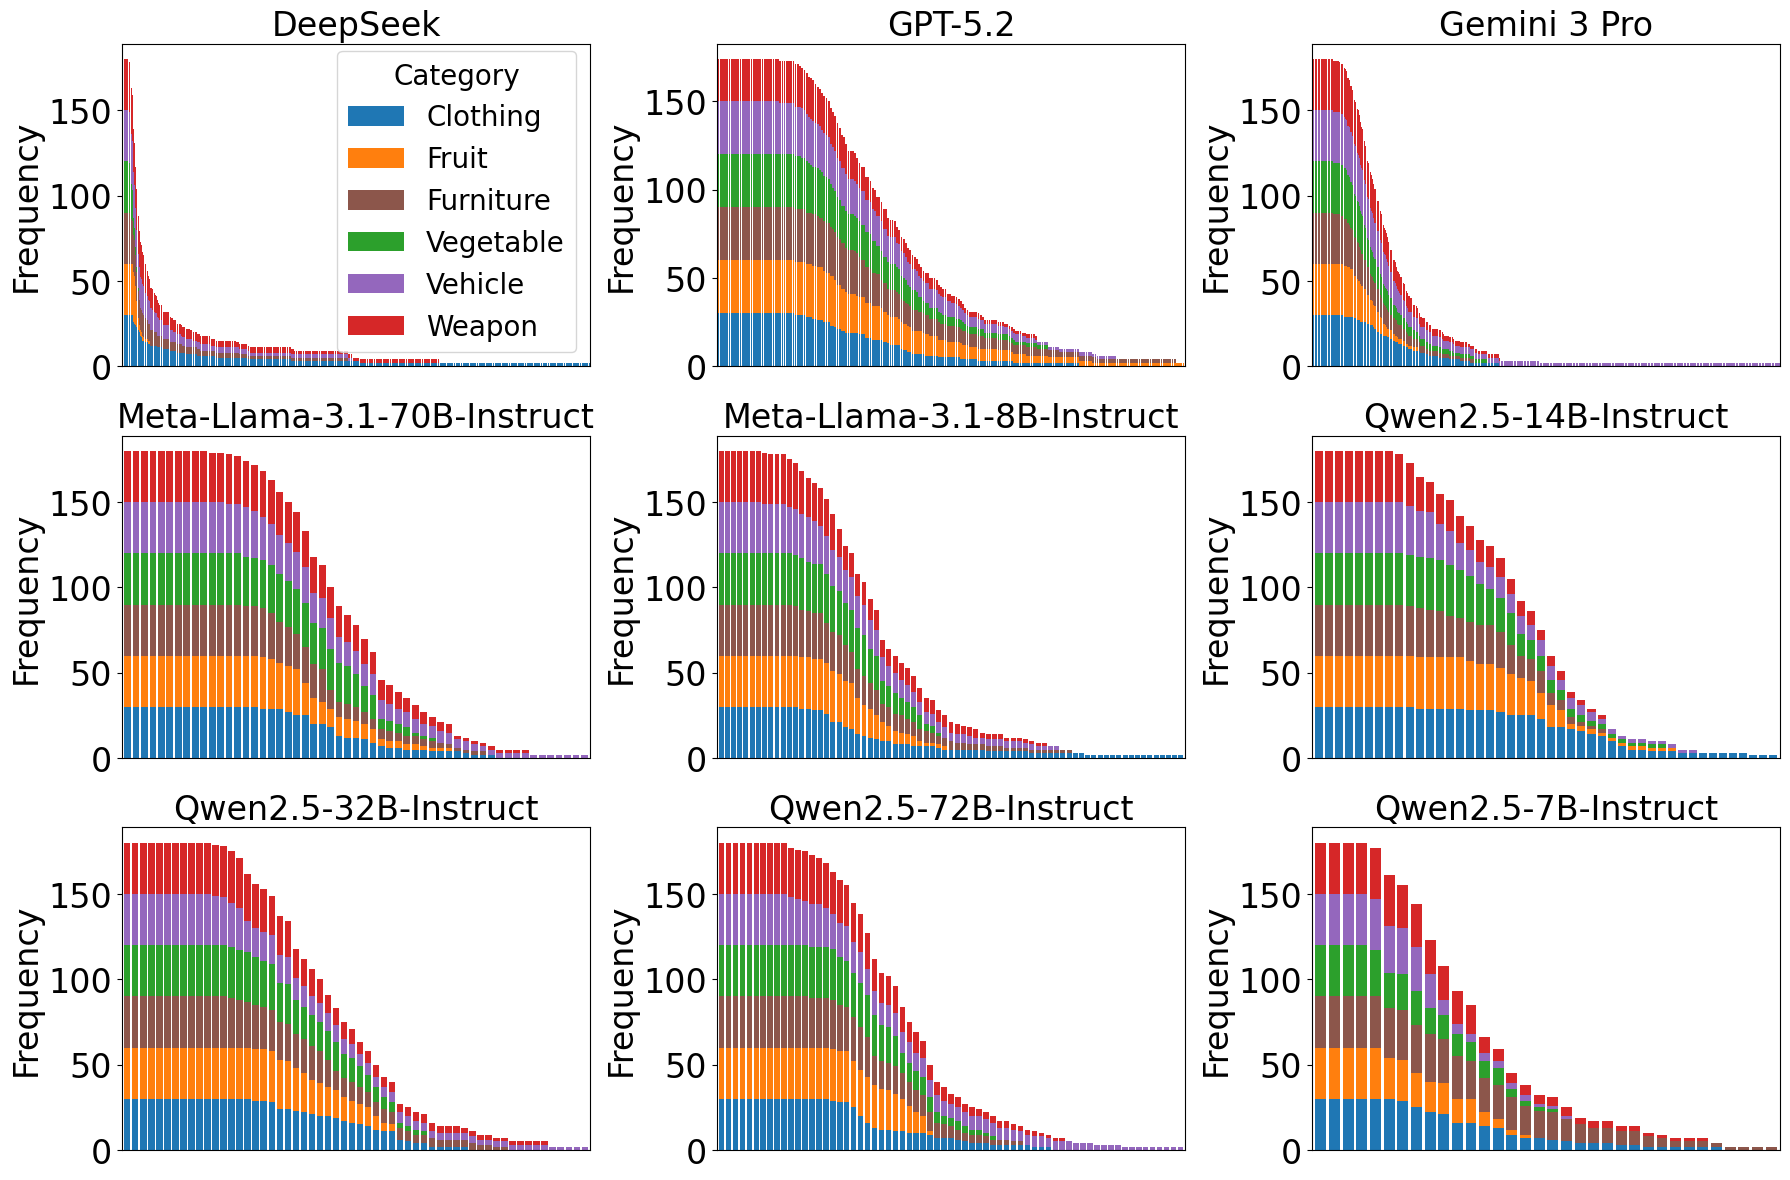

In [ ]:
TITLE_SIZE = 24
LABEL_SIZE = 24
TICK_SIZE = 24
LEGEND_SIZE = 20

plt.rcParams.update({
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': LEGEND_SIZE
})

model_items = items_df.explode('output_list_processed_nonoise') 
item_counts = model_items.groupby(
    ['model', 'category', 'output_list_processed_nonoise']
).size().reset_index(name='frequency')

item_counts['rank'] = item_counts.groupby(
    ['model', 'category']
)['frequency'].rank(method='first', ascending=False).astype(int)

unique_models = item_counts['model'].unique()
n_models = len(unique_models)

category_order = sorted(item_counts['category'].unique())

tab10 = plt.get_cmap('tab10').colors

category_color_map = {
    'Vegetable': tab10[2],  
    'Furniture': tab10[5],  
    'Weapon': tab10[3],     
}

remaining_categories = [c for c in category_order if c not in category_color_map]
unused_indices = [i for i in range(10) if i not in [2, 3, 5]]
unused_colors = [tab10[i] for i in unused_indices]

for cat, col in zip(remaining_categories, unused_colors):
    category_color_map[cat] = col

colors = [category_color_map[cat] for cat in category_order]

n_rows = 3
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12), sharex=False)
axes = axes.flatten()  

for i, model in enumerate(unique_models):
    if i >= n_rows * n_cols:
        break  

    ax = axes[i]
    model_data = item_counts[item_counts['model'] == model]
    
    pivot_df = model_data.pivot_table(
        index='rank',
        columns='category',
        values='frequency',
        fill_value=0
    )
    
    pivot_df = pivot_df.reindex(columns=category_order, fill_value=0)
    
    max_rank = pivot_df.index.max()
    pivot_df = pivot_df.reindex(range(1, max_rank + 1), fill_value=0)
    
    pivot_df = pivot_df.sort_index()
    
    # Plot
    pivot_df.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors,
        legend=(i == 0),  
        width=0.8
    )
    
    ax.margins(x=0)
    
    ax.set_title(f'{model}')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

    ax.set_xticks([])

    if i == 0:
        ax.legend(title='Category', fontsize=LEGEND_SIZE, title_fontsize=LEGEND_SIZE)

for j in range(i + 1, n_rows * n_cols):
    axes[j].axis('off') 

plt.tight_layout()

plt.savefig('01_ItemsFigures/figure_item_frequency_distributions.pdf', format='pdf', bbox_inches='tight')

plt.show()


In [ ]:
# FREQUENCY DISTRIBUTIONS AFTER FILTERING OUT NOISE

model_items = items_df.explode('output_list_processed_nonoise') 
item_counts = model_items.groupby(['model', 'category', 'output_list_processed_nonoise']).size().reset_index(name='frequency')

unique_models = item_counts['model'].unique()

for model in unique_models:
    plt.figure(figsize=(16, 10))  
    
    model_data = item_counts[item_counts['model'] == model]
    unique_categories = model_data['category'].unique()
    
    n_categories = len(unique_categories)
    
    for i, category in enumerate(unique_categories):
        plt.subplot((n_categories + 1) // 2, 2, i + 1)  
        
        category_data = model_data[model_data['category'] == category].sort_values(by='frequency', ascending=False)

        plt.bar(category_data['output_list_processed_nonoise'], category_data['frequency'])

        plt.title(f'{category}')
        plt.ylabel('Items Frequency')
       
        plt.xticks([])

    plt.suptitle(f'{model}', fontsize=16)  
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    plt.savefig(f'01_ItemsFigures/{model}_items_freqdist_nonoise.pdf', format='pdf')

    plt.show()

    plt.close()


In [ ]:
# FREQUENCY DISTRIBUTIONS AFTER FILTERING OUT NOISE + CURVE

model_items = items_df.explode('output_list_processed_nonoise') 
item_counts = model_items.groupby(['model', 'category', 'output_list_processed_nonoise']).size().reset_index(name='frequency')

unique_models = item_counts['model'].unique()

for model in unique_models:
    plt.figure(figsize=(16, 10))  

    model_data = item_counts[item_counts['model'] == model]
    unique_categories = model_data['category'].unique()
    
    n_categories = len(unique_categories)
 
    for i, category in enumerate(unique_categories):
        plt.subplot((n_categories + 1) // 2, 2, i + 1)  
        
        category_data = model_data[model_data['category'] == category].sort_values(by='frequency', ascending=False)

        plt.bar(category_data['output_list_processed_nonoise'], category_data['frequency'], color='lightblue', label='Frequency')

        degree = 5
        x = np.arange(len(category_data))
        y = category_data['frequency'].values

        coeffs = np.polyfit(x, y, degree)
        poly = np.poly1d(coeffs)

        x_curve = np.linspace(0, len(category_data) - 1, 100)
        y_curve = poly(x_curve)

        plt.plot(x_curve, y_curve, color='orange', label='Modeled Curve', linewidth=2)

        plt.title(f'{category}')
        plt.ylabel('Items Frequency')
        plt.xticks([])
        plt.legend()

    plt.suptitle(f'{model}', fontsize=16)  
    plt.tight_layout(rect=[0, 0, 1, 0.95])  

    plt.savefig(f'01_ItemsFigures/{model}_items_freqdist_nonoise_curve.pdf', format='pdf')
    plt.show()
    plt.close()

In [ ]:
model_items = items_df.explode('output_list_processed_nonoise') 
item_counts = model_items.groupby(['model', 'category', 'output_list_processed_nonoise']).size().reset_index(name='frequency')

unique_models = item_counts['model'].unique()
num_models = len(unique_models)

fig, axs = plt.subplots(nrows=(num_models) // 3, ncols=3, figsize=(12, 8), constrained_layout=True, sharey=True)
axs = axs.flatten() 

cmap = get_cmap('viridis', 10)  

for index, model in enumerate(unique_models):

    model_data = item_counts[item_counts['model'] == model]
    unique_categories = model_data['category'].unique()


    for category_index, category in enumerate(unique_categories):

        category_data = model_data[model_data['category'] == category].sort_values(by='frequency', ascending=False)

        x = np.arange(len(category_data))

        degree = 5
        y = category_data['frequency'].values

        coeffs = np.polyfit(x, y, degree)
        poly = np.poly1d(coeffs)

        x_curve = np.linspace(0, len(category_data) - 1, 100)
        y_curve = poly(x_curve)

        axs[index].fill_between(x_curve, y_curve, color=cmap(category_index), alpha=0.3)  
        axs[index].plot(x_curve, y_curve, color=cmap(category_index))  

    axs[index].set_title(f'{model}', fontsize=14)
    axs[index].set_ylabel('Frequency')
    axs[index].set_xlabel('Items')
    axs[index].set_xticks([])  

if num_models >= 10:
    axs[9].remove()  

handles = [plt.Line2D([0], [0], color=cmap(i), lw=2) for i in range(len(unique_categories))]
labels = unique_categories
fig.legend(handles, labels, title="Categories", loc='center left', bbox_to_anchor=(-0.2, 0.5))

plt.tight_layout(rect=[0, 0, 0.85, 1])  

plt.savefig('01_ItemsFigures/allmodels_items_freqdist_nonoise_curve_3.pdf', format='pdf')

plt.show()


In [ ]:
# Stratified Sampling of Items
# (Common Items & Rosch Items Priority)

def divide_samples_by_frequency(df):
    results = defaultdict(lambda: defaultdict(lambda: {'most_frequent': [], 'average_frequency': [], 'least_frequent': []}))

    for (model, category), group in df.groupby(['model', 'category']):
        
        items_count = group['output_list_processed_nonoise'].explode().value_counts()
        filtered_items = items_count[items_count > 1]  
        sorted_items = filtered_items.sort_values(ascending=False)

        n = len(sorted_items)
        if n == 0:
            continue
        
        min_freq = filtered_items.min()
        max_freq = filtered_items.max()

        range_size = (max_freq - min_freq) / 3 if max_freq > min_freq else 1
    
        thresholds = [min_freq + range_size * i for i in range(1, 3)]

        most_frequent = filtered_items[filtered_items >= thresholds[1]].index.tolist()  
        average_frequency = filtered_items[(filtered_items < thresholds[1]) & (filtered_items >= thresholds[0])].index.tolist()  
        least_frequent = filtered_items[filtered_items < thresholds[0]].index.tolist()  

        for freq_group, items in zip(['most_frequent', 'average_frequency', 'least_frequent'], 
                                      [most_frequent, average_frequency, least_frequent]):
            sampled_items = []

            common_items_per_category = set(common_items.get(category, []))
            for item in common_items_per_category:
                if item in items and len(sampled_items) < 6:
                    sampled_items.append(item)

            if category in rosch_items:
                rosch_set = rosch_items[category]
                available_rosch_items = [item for item in rosch_set if item not in sampled_items]

                if len(sampled_items) >= 6:
                    rosch_sample = random.sample(available_rosch_items, min(3, len(available_rosch_items)))
                    sampled_items.extend(rosch_sample)
                else:
                
                    for item in available_rosch_items:
                        if (item in items) and (len(sampled_items) < 6):
                            sampled_items.append(item)

            remaining_spots = 6 - len(sampled_items)
            if remaining_spots > 0:
                random_items = random.sample(
                    [item for item in items if item not in sampled_items], 
                    min(remaining_spots, len(items) - len(sampled_items))
                )
                sampled_items.extend(random_items)

            results[category][model][freq_group] = sampled_items[:6]

    return dict(results)

sampled_items_per_category_model = divide_samples_by_frequency(items_df)

In [27]:
# PLOT THE FREQUENCY DISTRIBUTION BASED ON INTERVALS


In [ ]:
# Example Category ("Furniture") Sampled Items

colors = {
        "reset": "\033[0m",
        "red": "\033[31m",    
        "yellow": "\033[33m", 
        "pink": "\033[35m",   
}

def print_furniture_items_with_colors(sampled_items_per_category_model, category="Furniture"):

    if category in sampled_items_per_category_model:
        print(f"{colors['reset']}Sampled Items for Category: {category}\n")
        
        for model, intervals in sampled_items_per_category_model[category].items():
            print(f"{colors['reset']}Model: {model}")
            for interval, items in intervals.items():
                colored_items = []
                for item in items:
                    if item in common_items.get(category, []):
                        if item in rosch_items.get(category, set()):
                            colored_items.append(f"{colors['red']}{item}{colors['reset']}")  # common & rosch
                        else:
                            colored_items.append(f"{colors['yellow']}{item}{colors['reset']}")  # common items only
                    elif item in rosch_items.get(category, set()):
                        colored_items.append(f"{colors['pink']}{item}{colors['reset']}")  # rosch items only
                    else:
                        colored_items.append(item)  # neither

                print(f"  {interval.replace('_', ' ').capitalize()} Items: {', '.join(colored_items) if colored_items else 'None'}")
            print()
    else:
        print(f"No sampled items found for category: {category}")

print("\nColors Legend: " + colors["yellow"] + "COMMON" + colors["reset"] + " - " + colors["pink"] + "ROSCH" + colors["reset"]  + " - " + colors["red"] + "COMMON&ROSCH" + colors["reset"]  + " - " + "UNIQUE" + colors["reset"])
print_furniture_items_with_colors(sampled_items_per_category_model, category="Furniture")



Colors Legend: COMMON - ROSCH - COMMON&ROSCH - UNIQUE
Sampled Items for Category: Furniture

Model: Meta-Llama-3.1-70B-Instruct
  Most frequent Items: coffee table, desk, ottoman, wardrobe, chair, sofa
  Average frequency Items: end table, futon
  Least frequent Items: couch, cabinet, bookcase, lamp, chest of drawer, daybed

Model: Meta-Llama-3.1-8B-Instruct
  Most frequent Items: coffee table, desk, ottoman, shelf, wardrobe, chair
  Average frequency Items: loveseat, end table, rug, tv stand, headboard
  Least frequent Items: sideboard, couch, dining table, closet, piano, cushion

Model: Qwen2.5-14B-Instruct
  Most frequent Items: coffee table, desk, ottoman, shelf, wardrobe, chair
  Average frequency Items: sideboard, bookshelf, bookcase, side table
  Least frequent Items: loveseat, end table, mirror, vanity, drawer, recliner

Model: Qwen2.5-32B-Instruct
  Most frequent Items: coffee table, desk, ottoman, wardrobe, chair, sofa
  Average frequency Items: shelf, armchair, mirror, lamp

In [ ]:
# Preparing all sampled items for Attributes Task

flattened_data = []

for category, models in sampled_items_per_category_model.items():
    for model, freq_groups in models.items():
        for freq_group, items in freq_groups.items():
            
            flattened_data.append({
                'model': model,
                'category': category,
                'frequency': freq_group,
                'items': items 
            })

items_for_attributes = pd.DataFrame(flattened_data)

In [30]:
items_for_attributes.head()

,model,category,frequency,items
0,Meta-Llama-3.1-70B-Instruct,Clothing,most_frequent,"[jean, sandal, sock, glove, coat, underwear]"
1,Meta-Llama-3.1-70B-Instruct,Clothing,average_frequency,"[vest, overall, belt, blouse, heel, robe]"
2,Meta-Llama-3.1-70B-Instruct,Clothing,least_frequent,"[pajama, leggings, apron, swimsuit, tight, sto..."
3,Meta-Llama-3.1-8B-Instruct,Clothing,most_frequent,"[sock, glove, coat, underwear, shoe, scarf]"
4,Meta-Llama-3.1-8B-Instruct,Clothing,average_frequency,"[short, sweater, blouse, gown, nightgown]"


In [31]:
#items_for_attributes.to_csv('01_catmemexp_attributestask_items4attributes.csv',index=False, quoting=csv.QUOTE_ALL, encoding='utf-8') #without gpt and deepseek
#items_for_attributes.to_csv('01_catmemexp_attributestask_items4attributes_2.csv',index=False, quoting=csv.QUOTE_ALL, encoding='utf-8') #with gpt and deepseek